# Libraries

In [19]:
LOCAL = True

In [ ]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
import numpy as np
from pyspark.sql.functions import (
    col, count, when, isnan,
    countDistinct,
    sum as _sum,
    unix_timestamp,
    count as spark_count,
    abs as spark_abs,
    hour, dayofweek, month, to_date,
    avg,
    concat, lit
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

# Spark Session

In [21]:
from pyspark.sql import SparkSession
if LOCAL:
  spark = SparkSession.builder.master("local[*]").appName("NYC_Taxi_Analysis").config("spark.driver.memory", "8g").getOrCreate()
else:
  spark = SparkSession.builder.appName("NYC_Taxi_Analysis").getOrCreate()

# Create taxi_df

In [22]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType

# Data path
if LOCAL:
  DATA_PATH = "./data/2020"
else:
  # O teu bucket no Dataproc
  DATA_PATH = "gs://nyc-taxi-data-27/data"

# Parquet files logic
if LOCAL:
  parquet_files = glob.glob(
    os.path.join(DATA_PATH, "*.parquet")
  )
  print(f"\nFound {len(parquet_files)} parquet files.")

  # Count total rows
  total_rows = 0
  for file in parquet_files:
      parquet_file = pq.ParquetFile(file)
      rows = parquet_file.metadata.num_rows
      print(f"{os.path.basename(file)} -> {rows:,} rows")
      total_rows += rows

  print("\n=========================")
  print(f"TOTAL ROWS: {total_rows:,}")
  print("=========================")
else:
  parquet_path = f"{DATA_PATH}/*.parquet"

# 1. Define explicitly the type of each column (Fixed: Using TimestampType instead of TimestampNTZType)
taxi_schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),  # <-- AQUI ESTÁ A CORREÇÃO
    StructField("tpep_dropoff_datetime", TimestampType(), True), # <-- AQUI ESTÁ A CORREÇÃO
    StructField("passenger_count", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", DoubleType(), True),
    StructField("store_and_fwd_flag", StringType(), True),
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True)
])

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# 2. Read files
if LOCAL:
  taxi_df = spark.read.schema(taxi_schema).parquet(*parquet_files)
else:
  taxi_df = spark.read.schema(taxi_schema).parquet(parquet_path)

print("\nDataset loaded successfully with explicit schema!")

# Dataset info
print("\n=========================")
print("TOTAL ROWS:", taxi_df.count())
print("TOTAL COLUMNS:", len(taxi_df.columns))
print("=========================")

# Load taxi_zone_lookup.csv
zone_df = spark.read.csv(
    f"{DATA_PATH}/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)

print("\nTaxi Zone Lookup Preview:")
zone_df.show(5)

# Pickup join
pickup_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "PULocationID")
    .withColumnRenamed("Borough", "PU_Borough")
    .withColumnRenamed("Zone", "PU_Zone")
    .withColumnRenamed("service_zone", "PU_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(pickup_lookup),
    on="PULocationID",
    how="left"
)

print("\nPickup join completed!")

# Dropoff join
dropoff_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "DOLocationID")
    .withColumnRenamed("Borough", "DO_Borough")
    .withColumnRenamed("Zone", "DO_Zone")
    .withColumnRenamed("service_zone", "DO_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(dropoff_lookup),
    on="DOLocationID",
    how="left"
)

print("\nDropoff join completed!")

# Final dataset info
print("\nFinal Schema:")
taxi_df.printSchema()

print("\nFinal Dataset Preview:")
taxi_df.show(5)



Found 12 parquet files.
yellow_tripdata_2020-05.parquet -> 348,415 rows
yellow_tripdata_2020-12.parquet -> 1,461,898 rows
yellow_tripdata_2020-04.parquet -> 238,073 rows
yellow_tripdata_2020-09.parquet -> 1,341,017 rows
yellow_tripdata_2020-10.parquet -> 1,681,132 rows
yellow_tripdata_2020-08.parquet -> 1,007,286 rows
yellow_tripdata_2020-03.parquet -> 3,007,687 rows
yellow_tripdata_2020-06.parquet -> 549,797 rows
yellow_tripdata_2020-07.parquet -> 800,412 rows
yellow_tripdata_2020-01.parquet -> 6,405,008 rows
yellow_tripdata_2020-02.parquet -> 6,299,367 rows
yellow_tripdata_2020-11.parquet -> 1,509,000 rows

TOTAL ROWS: 24,649,092

Dataset loaded successfully with explicit schema!



TOTAL ROWS: 24649092
TOTAL COLUMNS: 19

Taxi Zone Lookup Preview:
+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows

Pickup join completed!

Dropoff join completed!

Final Schema:
root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_di

# **Dataset Overview**

### **1. Dataset Structure**

The dataset consists of a single unified table (after joining the location lookup tables) with **24,649,092 observations** and **25 variables**, occupying approximately **~1.5 GB** of storage across multiple Parquet files. It is stored in a distributed Big Data format and loaded into a PySpark DataFrame for analysis.

Each row represents **one yellow taxi trip** in New York City during the year 2020, integrating timestamp, location, and financial billing information.

---

### **2. Granularity**

The dataset is at **trip-level granularity**, where each observation corresponds to a single taxi ride, combining:

* **Temporal data:** Exact pickup and dropoff timestamps.
* **Geospatial data:** Origin and destination boroughs, zones, and service areas.
* **Operational data:** Passenger count, trip distance, and rate codes.
* **Financial data:** Itemized breakdown of the final cost (base fare, taxes, surcharges, and tips).

---

### **3. Dimensionality**

* Total variables: **25**
* Moderate dimensionality with massive volume.

Key aspects:

* Enriched dimensionality via Joins (Location IDs were expanded into 6 descriptive text columns).
* Presence of highly granular continuous variables (distances and itemized financials).
* Implicit logical dependencies (e.g., `total_amount` is a strict sum of all other financial columns).

---

### **4. Data Dictionary (Variables and Types)**

| Variable | Type | Description |
| --- | --- | --- |
| VendorID | Categorical (numeric ID) | TPEP provider (1=Creative Mobile, 2=VeriFone) |
| tpep_pickup_datetime | Datetime | Date and time the meter was engaged |
| tpep_dropoff_datetime | Datetime | Date and time the meter was disengaged |
| passenger_count | Numeric (discrete) | Number of passengers in the vehicle |
| trip_distance | Numeric (continuous) | Elapsed trip distance in miles |
| RatecodeID | Categorical (numeric ID) | Final rate code (1=Standard, 2=JFK, etc.) |
| store_and_fwd_flag | Categorical (binary) | Trip data held in vehicle memory before sending (Y/N) |
| PULocationID | Identifier (numeric) | TLC Taxi Zone in which the meter was engaged |
| DOLocationID | Identifier (numeric) | TLC Taxi Zone in which the meter was disengaged |
| payment_type | Categorical (numeric ID) | How the passenger paid (1=Credit card, 2=Cash, etc.) |
| fare_amount | Numeric (continuous) | Time-and-distance fare calculated by the meter |
| extra | Numeric (continuous) | Miscellaneous extras and surcharges |
| mta_tax | Numeric (continuous) | $0.50 MTA tax |
| tip_amount | Numeric (continuous) | Tip amount (credit card tips only) |
| tolls_amount | Numeric (continuous) | Total amount of all tolls |
| improvement_surcharge | Numeric (continuous) | $0.30 improvement surcharge |
| total_amount | Numeric (continuous) | Total amount charged to passengers |
| congestion_surcharge | Numeric (continuous) | Surcharge for trips in the Manhattan congestion zone |
| airport_fee | Numeric (continuous) | Surcharge for airport pickups/dropoffs |
| PU_Borough | Categorical (nominal) | Origin Borough (e.g., Manhattan, Queens) |
| PU_Zone | Categorical (nominal) | Origin detailed Zone |
| PU_service_zone | Categorical (nominal) | Origin service zone rule (e.g., Yellow Zone, Boro Zone) |
| DO_Borough | Categorical (nominal) | Destination Borough |
| DO_Zone | Categorical (nominal) | Destination detailed Zone |
| DO_service_zone | Categorical (nominal) | Destination service zone rule |

---

### **5. Variable Typing Summary**

**Numerical (Continuous)**

* Core Financials: `fare_amount`, `tip_amount`, `total_amount`
* Surcharges/Taxes: `extra`, `mta_tax`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `airport_fee`
* Metrics: `trip_distance`

**Numerical (Discrete)**

* `passenger_count`

**Categorical (Nominal / IDs)**

* System/Rules: `VendorID`, `RatecodeID`, `payment_type`, `store_and_fwd_flag`
* Geography: `PULocationID`, `DOLocationID`, `PU_Borough`, `PU_Zone`, `PU_service_zone`, `DO_Borough`, `DO_Zone`, `DO_service_zone`

**Datetime**

* `tpep_pickup_datetime`, `tpep_dropoff_datetime`

---

### **6. Cardinality**

* **Low:** `VendorID` (4), `store_and_fwd_flag` (2), `payment_type` (6), `Boroughs` (7).
* **Medium:** `RatecodeID`, `passenger_count`.
* **High:** `PULocationID` / `DOLocationID` (260+ zones), `trip_distance`, Financial amounts, Datetimes.

---

### **7. Volume of Data**

* Rows: **24,649,092**
* Columns: **25**
* Size: **~1.5 GB** (compressed Parquet format)

Dataset operates at Big Data scale, requiring distributed computing (Apache Spark) for efficient processing and aggregation.

---

### **8. Data Quality**

**Completeness**

* Core trip variables (distances, datetimes) are highly complete.
* Missing values are present predominantly in dynamically changing policy fields (e.g., `airport_fee`, `congestion_surcharge`) and occasionally in `passenger_count` and `RatecodeID`.

**Consistency & Outliers**

* **System Errors:** Presence of severe negative values across financial columns (e.g., negative `fare_amount` and `total_amount`), likely indicating reversed transactions or system glitches.
* **Extreme Anomalies:** `trip_distance` contains impossible values (e.g., negative distances and distances exceeding tens of thousands of miles).
* **Data Type Mismatches:** The raw `airport_fee` column contained integer types in certain monthly partitions that required bypassing the vectorized reader for safe conversion to double.

**Duplicates**

* Given the scale and nature of meter generated data, exact row duplicates are highly improbable unless a system replay occurred (requires specific validation).

---

### **9. Key Observations**

* The dataset is incredibly rich but strictly requires a **Data Cleaning phase** before any statistical modeling or machine learning.
* Geographical joins were successfully executed, enabling macro-level spatial analysis (Boroughs) instead of just micro-level (Zones).
* Strict filtering rules must be applied to bound `trip_distance` > 0 and `fare_amount` > 0 to establish a physically and logically possible baseline.

In [23]:
# Volume and Dimensionality
print(f"Rows: {taxi_df.count():,}")
print(f"Columns: {len(taxi_df.columns)}")

# Schema
taxi_df.printSchema()

# Cardinality
print("Cardinality Check...")
categorical_cols = ["VendorID", "store_and_fwd_flag", "payment_type", "RatecodeID", "PU_Borough"]
taxi_df.select([countDistinct(c).alias(c) for c in categorical_cols]).show()


Rows: 24,649,092
Columns: 25
root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- PU_Borough: string (nullable = true)
 |-- PU_Zone: string (nullable = true)
 |-- PU_service_zone: string 

+--------+------------------+------------+----------+----------+
|VendorID|store_and_fwd_flag|payment_type|RatecodeID|PU_Borough|
+--------+------------------+------------+----------+----------+
|       4|                 2|           6|         7|         7|
+--------+------------------+------------+----------+----------+



## **Data Understanding**

### **Data Quality**

### Missing Values

In [24]:
missing_df = taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in taxi_df.columns
])

missing_df.show(truncate=False)

+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+-------+---------------+
|DOLocationID|PULocationID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|PU_Borough|PU_Zone|PU_service_zone|DO_Borough|DO_Zone|DO_service_zone|
+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+--

/tmp/ipykernel_622019/4057369365.py:29: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


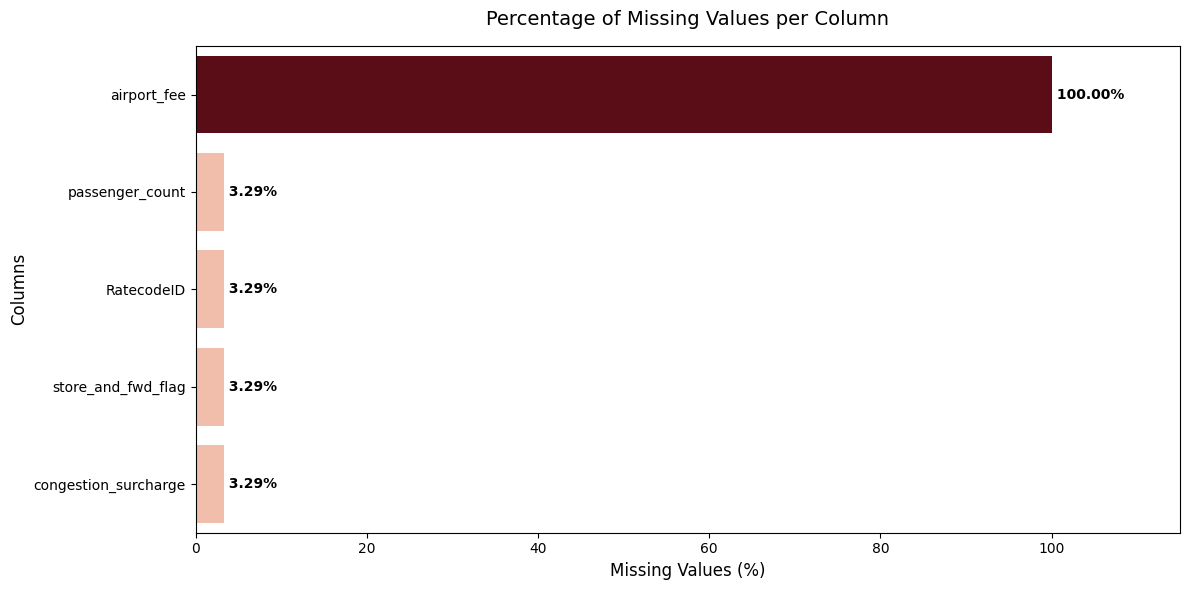

In [ ]:
# 1. Prepare data
missing_pd = missing_df.toPandas()
missing_pd_melted = missing_pd.melt(var_name='Column', value_name='Missing_Values')
missing_pd_melted = missing_pd_melted[missing_pd_melted['Missing_Values'] > 0]

# 2. Calculate percentage
TOTAL_ROWS = 24649092
missing_pd_melted['Percentage'] = (missing_pd_melted['Missing_Values'] / TOTAL_ROWS) * 100
missing_pd_melted = missing_pd_melted.sort_values(by='Percentage', ascending=False)

# 3. MANUAL COLOR MAPPING (Fixed: Avoids hue_norm error)
max_pct = missing_pd_melted['Percentage'].max()
# We create a normalization object that avoids pure white (vmin)
norm = mcolors.Normalize(vmin=-max_pct * 0.3, vmax=max_pct)
mapper = cm.ScalarMappable(norm=norm, cmap='Reds')

# Assign a specific hex color to each row based on its percentage
missing_pd_melted['BarColor'] = [mapper.to_rgba(p) for p in missing_pd_melted['Percentage']]

# 4. Create the chart
plt.figure(figsize=(12, 6))

# We pass the pre-calculated colors directly to 'palette' or 'color'
sns.barplot(
    data=missing_pd_melted,
    x='Percentage',
    y='Column',
    palette=list(missing_pd_melted['BarColor'])
)

plt.title('Percentage of Missing Values per Column', fontsize=14, pad=15)
plt.xlabel('Missing Values (%)', fontsize=12)
plt.ylabel('Columns', fontsize=12)

# Extend X-axis slightly
plt.xlim(0, max_pct * 1.15)

# Add labels
for index, row in enumerate(missing_pd_melted.itertuples()):
    plt.text(row.Percentage, index, f' {row.Percentage:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Outliers

Calculating statistics for the Dashboard...


Generating Master Dashboard...


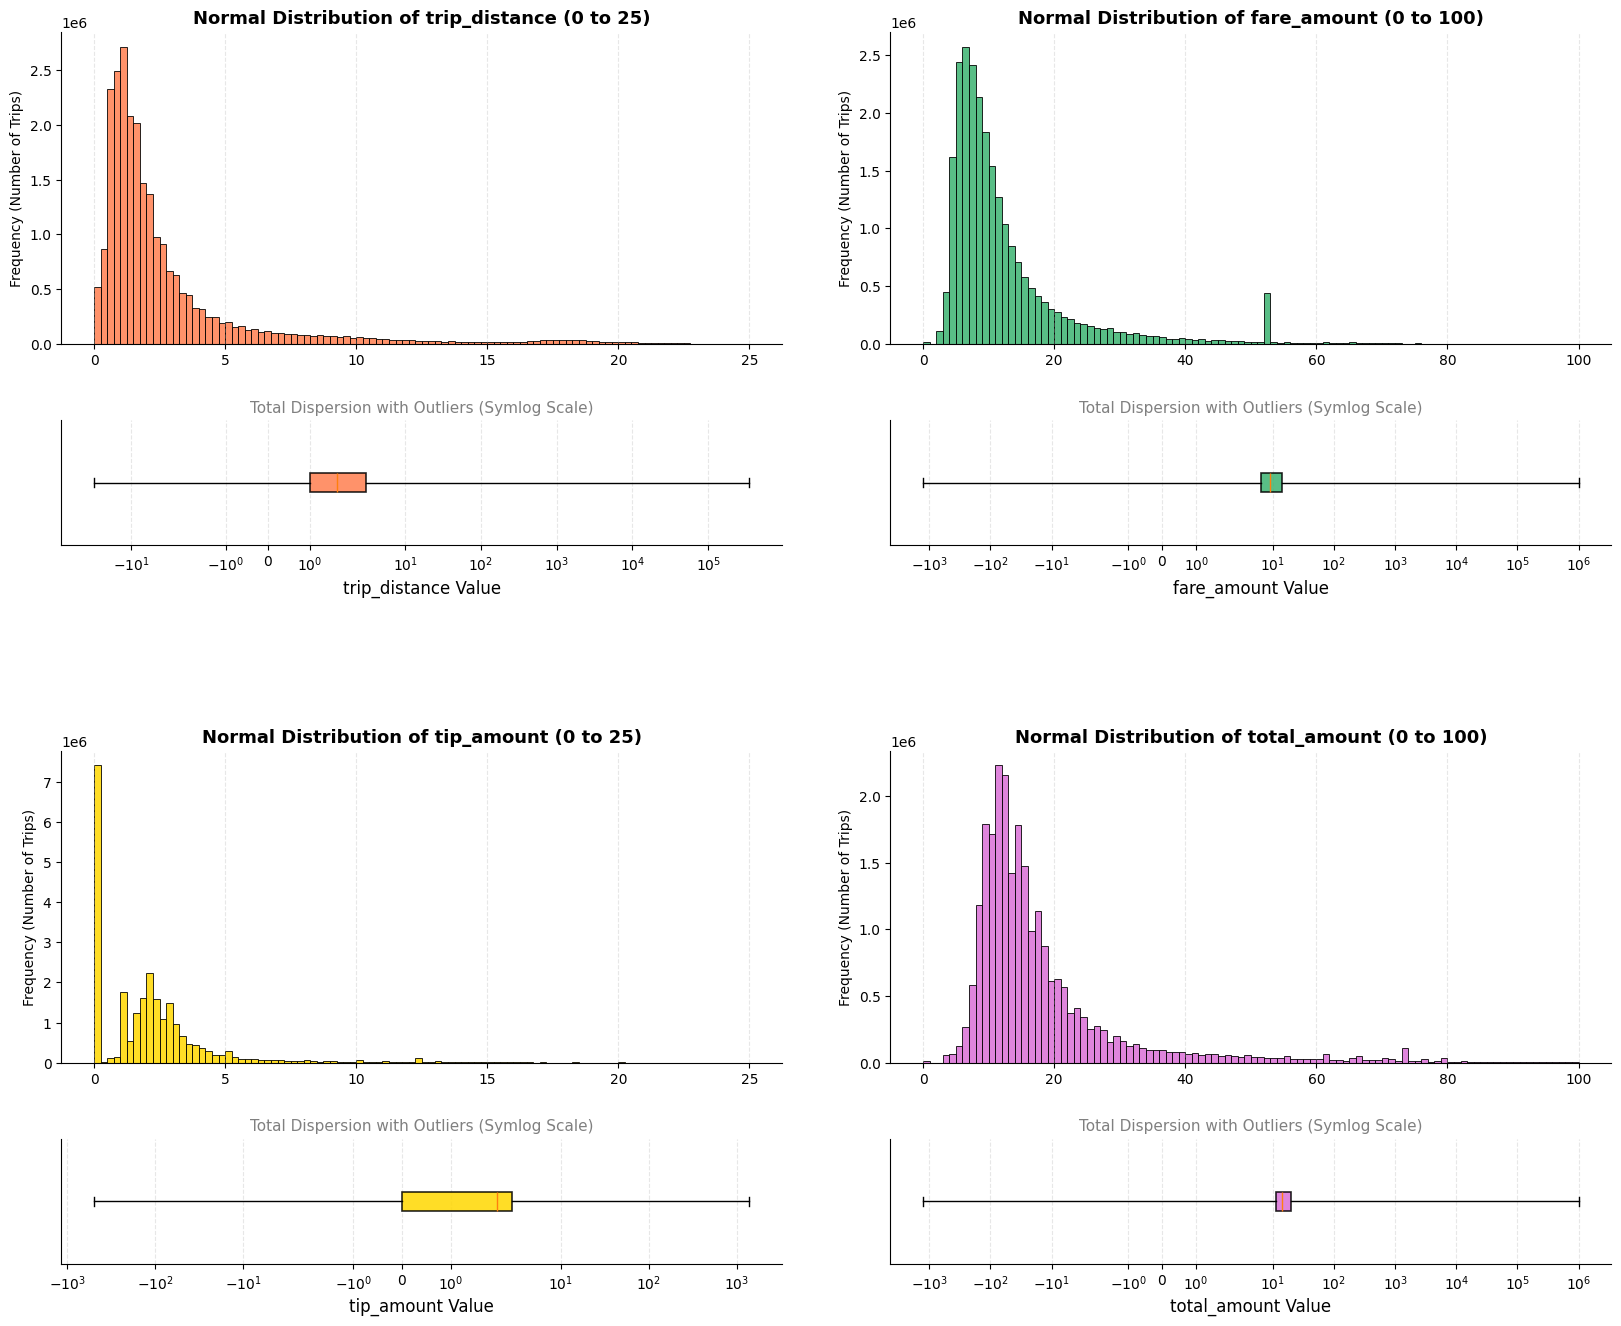

In [ ]:
# 1. Function to calculate Boxplot statistics safely via Spark
def get_spark_boxplot_data(df, column):
    stats = df.select(column).dropna().approxQuantile(column, [0.0, 0.25, 0.5, 0.75, 1.0], 0.01)
    return {"min": stats[0], "q1": stats[1], "med": stats[2], "q3": stats[3], "max": stats[4]}

print("Calculating statistics for the Dashboard...")

# Define strict limits for high granularity in the core range
# Format: (Column_Name, Color, Min_Limit, Max_Limit)
cols_to_analyze = [
    ("trip_distance", "coral", 0, 25), 
    ("fare_amount", "mediumseagreen", 0, 100), 
    ("tip_amount", "gold", 0, 25), 
    ("total_amount", "orchid", 0, 100)
]

# Store stats in a dictionary to avoid recalculating
box_data = {c_name: get_spark_boxplot_data(taxi_df, c_name) for c_name, _, _, _ in cols_to_analyze}

# =====================================================================
# MASTER DASHBOARD: HIGH GRANULARITY & OUTLINED BARS
# =====================================================================
print("Generating Master Dashboard...")

fig = plt.figure(figsize=(20, 16)) # Slightly taller to give breathing room
outer_gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.15)

for i, (column, color, min_val, max_val) in enumerate(cols_to_analyze):
    stats = box_data[column]

    # Split the areas (Ratio 2.5 to 1)
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, 
        subplot_spec=outer_gs[i], 
        height_ratios=[2.5, 1], 
        hspace=0.35 # Extra space since X-axes are now independent
    )

    # NO shared X-axis (removed sharex)
    ax_hist = fig.add_subplot(inner_gs[0])
    ax_box = fig.add_subplot(inner_gs[1])

    # --- 1. HISTOGRAM (Magnifying glass on the 'Normal' range) ---
    # Strictly filter for the normal range and increase bins to 100
    target_df = taxi_df.filter((col(column) >= min_val) & (col(column) <= max_val))
    hist_data = target_df.select(column).rdd.flatMap(lambda x: x).histogram(100)

    # Added edgecolor and linewidth for the perfect outline
    ax_hist.bar(hist_data[0][:-1], hist_data[1], width=np.diff(hist_data[0]), 
                align='edge', color=color, alpha=0.85, 
                edgecolor='black', linewidth=0.7)

    # --- 2. BOXPLOT (Global View including Outliers) ---
    ax_box.bxp([{
        'whislo': stats['min'], 'q1': stats['q1'], 'med': stats['med'], 
        'q3': stats['q3'], 'whishi': stats['max']
    }], vert=False, patch_artist=True, showfliers=False)

    # Style the Boxplot with outlines
    for patch in ax_box.patches:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)

    # --- FINAL STYLING ---
    ax_hist.set_title(f'Normal Distribution of {column} ({min_val} to {max_val})', fontweight='bold', fontsize=13)
    ax_hist.set_ylabel('Frequency (Number of Trips)')

    ax_box.set_title(f'Total Dispersion with Outliers (Symlog Scale)', fontsize=11, color='gray')
    ax_box.set_xlabel(f'{column} Value', fontsize=12)

    # Only the boxplot uses the logarithmic scale to shrink the extremes
    ax_box.set_xscale('symlog')

    # Clean up design (remove top and right borders)
    for ax in [ax_hist, ax_box]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', alpha=0.3, linestyle='--')

    ax_box.set_yticks([]) # Remove empty Y-axis from the boxplot

plt.show()

Aggregating categorical data using Spark. Please wait...


/tmp/ipykernel_622019/1693827314.py:59: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_622019/1693827314.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_622019/1693827314.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


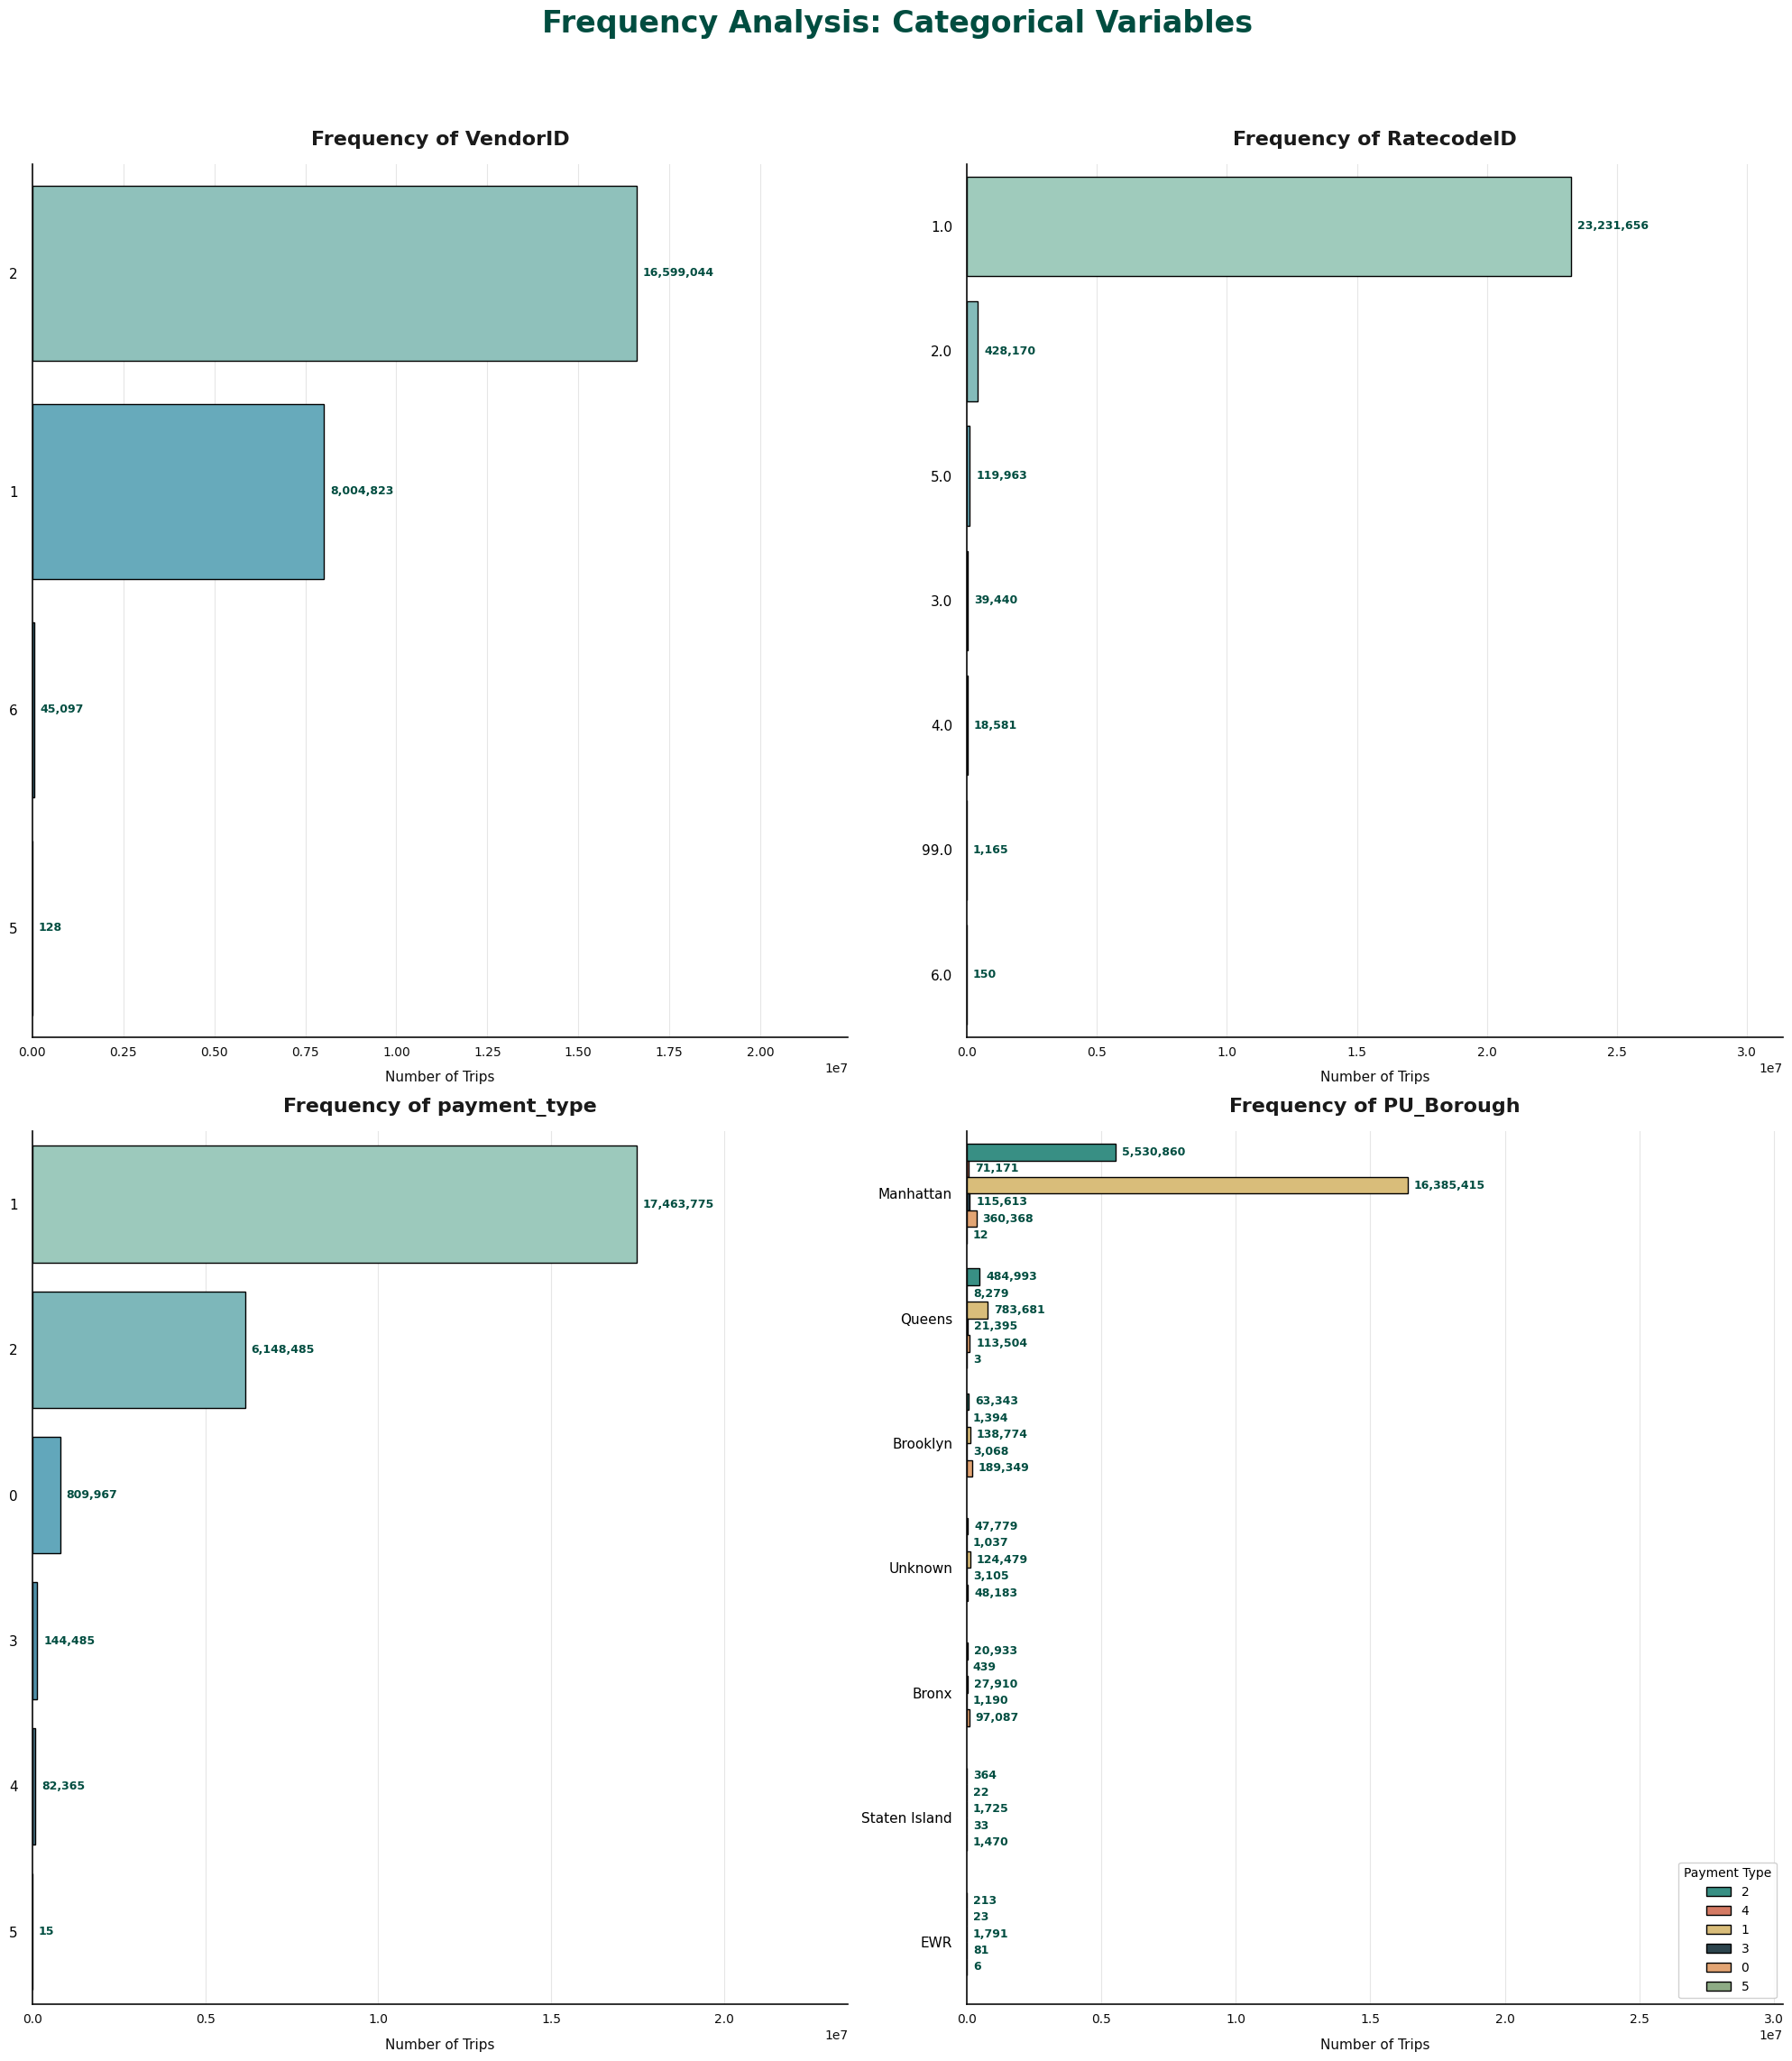

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 24))

fig.suptitle(
    'Frequency Analysis: Categorical Variables',
    fontsize=24,
    fontweight='bold',
    color='#004d40'
)

axes = axes.flatten()

cat_cols = ['VendorID', 'RatecodeID', 'payment_type', 'PU_Borough']

print("Aggregating categorical data using Spark. Please wait...")
cat_data = {}

for col_name in cat_cols:
    if col_name == 'PU_Borough':
        pdf = taxi_df.groupBy('PU_Borough', 'payment_type').count().toPandas()
        pdf['payment_type'] = pdf['payment_type'].astype(str)
    else:
        pdf = taxi_df.groupBy(col_name).count().orderBy("count", ascending=False).toPandas()

    pdf = pdf.dropna()
    pdf[col_name] = pdf[col_name].astype(str)
    cat_data[col_name] = pdf

# LOOP
for i, col_name in enumerate(cat_cols):
    ax = axes[i]
    df_plot = cat_data[col_name]

    if col_name == 'PU_Borough':
        max_val = df_plot.groupby('PU_Borough')['count'].sum().max()
    else:
        max_val = df_plot['count'].max()

    # SPECIAL CASE: PU_Borough
    if col_name == 'PU_Borough':
        order = df_plot.groupby('PU_Borough')['count'].sum().sort_values(ascending=False).index

        sns.barplot(
            data=df_plot,
            y='PU_Borough',
            x='count',
            hue='payment_type',
            order=order,
            ax=ax,
            palette=['#2a9d8f', '#e76f51', '#e9c46a', '#264653', '#f4a261', '#8ab17d'],
            edgecolor='black'
        )
        ax.legend(title='Payment Type', loc='lower right', framealpha=0.9)

    else:
        sns.barplot(
            data=df_plot,
            y=col_name,
            x='count',
            ax=ax,
            palette='GnBu_d',
            order=df_plot.sort_values('count', ascending=False)[col_name],
            edgecolor='black'
        )

    for p in ax.patches:
        width = p.get_width()

        if width > 0 and not np.isnan(width):
            ax.annotate(
                f'{int(width):,}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left',
                va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                color='#004d40'
            )

    # STYLE
    ax.set_title(f'Frequency of {col_name}', fontsize=16, fontweight='bold', pad=15, color='#1a1a1a')
    ax.set_xlabel('Number of Trips', fontsize=11, color='#0c0c0c', labelpad=10)
    ax.set_ylabel('')

    ax.set_axisbelow(True)
    ax.grid(axis='x', color='#e0e0e0', linestyle='-', alpha=0.8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color("#0c0c0c")
    ax.spines['left'].set_linewidth(1.2)

    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color("#0c0c0c")
    ax.spines['bottom'].set_linewidth(1.2)

    ax.tick_params(axis='y', which='major', left=False, pad=8, labelsize=11)

    ax.tick_params(axis='x', which='major', bottom=False, labelsize=10, colors='#0c0c0c')

    ax.set_xlim(0, max_val * 1.35)

# LAYOUT FIX
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Inconsistencies

In [ ]:
# Duplicate Rows

total_rows = taxi_df.count()
unique_rows = taxi_df.distinct().count()

print(f"Total Rows: {total_rows:,}")
print(f"Duplicate Rows: {total_rows - unique_rows:,}")

# Time Anomalies

# Add duration column in minutes for analysis
taxi_df = taxi_df.withColumn("duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
)

# 1. Dropoff before Pickup
time_errors = taxi_df.filter(col("tpep_dropoff_datetime") <= col("tpep_pickup_datetime")).count()

# 2. Excessively long trips (e.g., > 24 hours)
long_trips = taxi_df.filter(col("duration_min") > 1440).count()

print(f"Negative/Zero Duration: {time_errors:,}")
print(f"Trips > 24h: {long_trips:,}\n")

# Distance and Speed Anomalies

# 1. Zero or negative distance
dist_errors = taxi_df.filter(col("trip_distance") <= 0).count()

# 2. Impossible speed (e.g., > 100 mph)
# Speed = Distance / (Duration in hours)
speed_outliers = taxi_df.filter(
    (col("duration_min") > 1) &
    ((col("trip_distance") / (col("duration_min") / 60)) > 100)
).count()

print(f"Zero/Negative Distance: {dist_errors:,}")
print(f"Impossible Speeds (>100mph): {speed_outliers:,}\n")

# Fare and Amount Anomalies

# 1. Negative fares
fare_errors = taxi_df.filter(col("fare_amount") < 0).count()

# 2. Incorrect sum (Check if Total = Sum of all components)
# Using spark_abs (PySpark's abs) instead of native Python abs
sum_mismatch = taxi_df.filter(
    spark_abs(col("total_amount") - (
        col("fare_amount") + col("extra") + col("mta_tax") + 
        col("tip_amount") + col("tolls_amount") + col("improvement_surcharge") + 
        col("congestion_surcharge") + col("airport_fee")
    )) > 0.1
).count()

print(f"Negative Fare Amounts: {fare_errors:,}")
print(f"Total Amount Mismatches: {sum_mismatch:,}\n")

# Passenger Count and Ratecode Anomalies

# 1. Zero or negative passengers
pass_errors = taxi_df.filter((col("passenger_count") <= 0) | (col("passenger_count") > 9)).count()

# 2. Invalid RatecodeID (NYC defines only 1 to 6)
rate_errors = taxi_df.filter(~col("RatecodeID").isin([1, 2, 3, 4, 5, 6])).count()

print(f"Passenger Count Errors: {pass_errors:,}")
print(f"Invalid RateCodes: {rate_errors:,}\n")

# Summary of Inconsistencies
results = [
    ("Duplicate Rows", total_rows - unique_rows),
    ("Negative Duration", time_errors),
    ("Zero/Negative Distance", dist_errors),
    ("Negative Fares", fare_errors),
    ("Invalid Passenger Count", pass_errors),
    ("Invalid RateCodes", rate_errors)
]

print("\nSummary of Data Inconsistencies:")
print(f"{'Inconsistency Type':<30} | {'Count':<15}")
print("-" * 50)
for label, value in results:
    print(f"{label:<30} | {value:<15,}")

Total Rows: 24,649,092
Duplicate Rows: 12,950


Negative/Zero Duration: 37,412
Trips > 24h: 55



Zero/Negative Distance: 332,448
Impossible Speeds (>100mph): 1,306



Negative Fare Amounts: 92,833
Total Amount Mismatches: 14



Passenger Count Errors: 489,385
Invalid RateCodes: 1,165


Summary of Data Inconsistencies:
Inconsistency Type             | Count          
--------------------------------------------------
Duplicate Rows                 | 12,950         
Negative Duration              | 37,412         
Zero/Negative Distance         | 332,448        
Negative Fares                 | 92,833         
Invalid Passenger Count        | 489,385        
Invalid RateCodes              | 1,165          


## **Data Cleaning**

### Cleaning Missing Values

In [ ]:
print("Applying contextual imputation (Business Rules)...")

taxi_df = taxi_df \
    .withColumn(
        "RatecodeID",
        when(col("RatecodeID").isNull(),
             # If origin or destination is JFK (Zone ID 132 is JFK), apply RateCode 2
             when((col("PULocationID") == 132) | (col("DOLocationID") == 132), 2.0)
             # Otherwise, apply the standard fare (1)
             .otherwise(1.0)
        ).otherwise(col("RatecodeID"))
    ) \
    .withColumn(
        "congestion_surcharge",
        when(col("congestion_surcharge").isNull(),
             # If started or ended in Manhattan, apply the $2.50 fee
             when((col("PU_Borough") == 'Manhattan') | (col("DO_Borough") == 'Manhattan'), 2.5)
             .otherwise(0.0)
        ).otherwise(col("congestion_surcharge"))
    ) \
    .fillna({"passenger_count": 1.0}) \
    .fillna({"store_and_fwd_flag": "N"})

taxi_df = taxi_df.drop("airport_fee")

print("Contextual imputation completed!")

# Re-check for nulls to ensure they are 0
taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in ["passenger_count", "RatecodeID", "store_and_fwd_flag", "congestion_surcharge"]
]).show()


Applying contextual imputation (Business Rules)...
Contextual imputation completed!


+---------------+----------+------------------+--------------------+
|passenger_count|RatecodeID|store_and_fwd_flag|congestion_surcharge|
+---------------+----------+------------------+--------------------+
|              0|         0|                 0|                   0|
+---------------+----------+------------------+--------------------+



### Cleaning Inconsistencies

In [ ]:
# 1. Deduplication
taxi_df = taxi_df.dropDuplicates()

# 2. Add temporary duration for filtering
taxi_df = taxi_df.withColumn("duration_h",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 3600
)

# 3. Apply all Business Rules
taxi_df = taxi_df.filter(
    (col("duration_h") > 0) & (col("duration_h") < 24) &             # Logical time
    (col("trip_distance") > 0) & (col("trip_distance") < 500) &      # Physical distance
    (col("fare_amount") > 0) & (col("total_amount") > 0) &           # Financial logic
    (col("passenger_count") > 0) & (col("passenger_count") < 10) &   # Reality check
    (col("RatecodeID").isin([1, 2, 3, 4, 5, 6]))                     # Official codes
)

# 4. Remove speed outliers (Average speed < 100 mph)
taxi_df = taxi_df.filter((col("trip_distance") / col("duration_h")) < 100)

# 5. Drop the temporary column
taxi_df = taxi_df.drop("duration_h")

# Final check
print(f"Original rows: {total_rows:,}")
print(f"Cleaned rows: {taxi_df.count():,}")
print(f"Data loss: {((total_rows - taxi_df.count()) / total_rows) * 100:.2f}%")

Original rows: 24,649,092


Cleaned rows: 23,693,608


Data loss: 3.88%


### Data Exploration

Temporal Analysis

/tmp/ipykernel_622019/3429307602.py:82: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_622019/3429307602.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


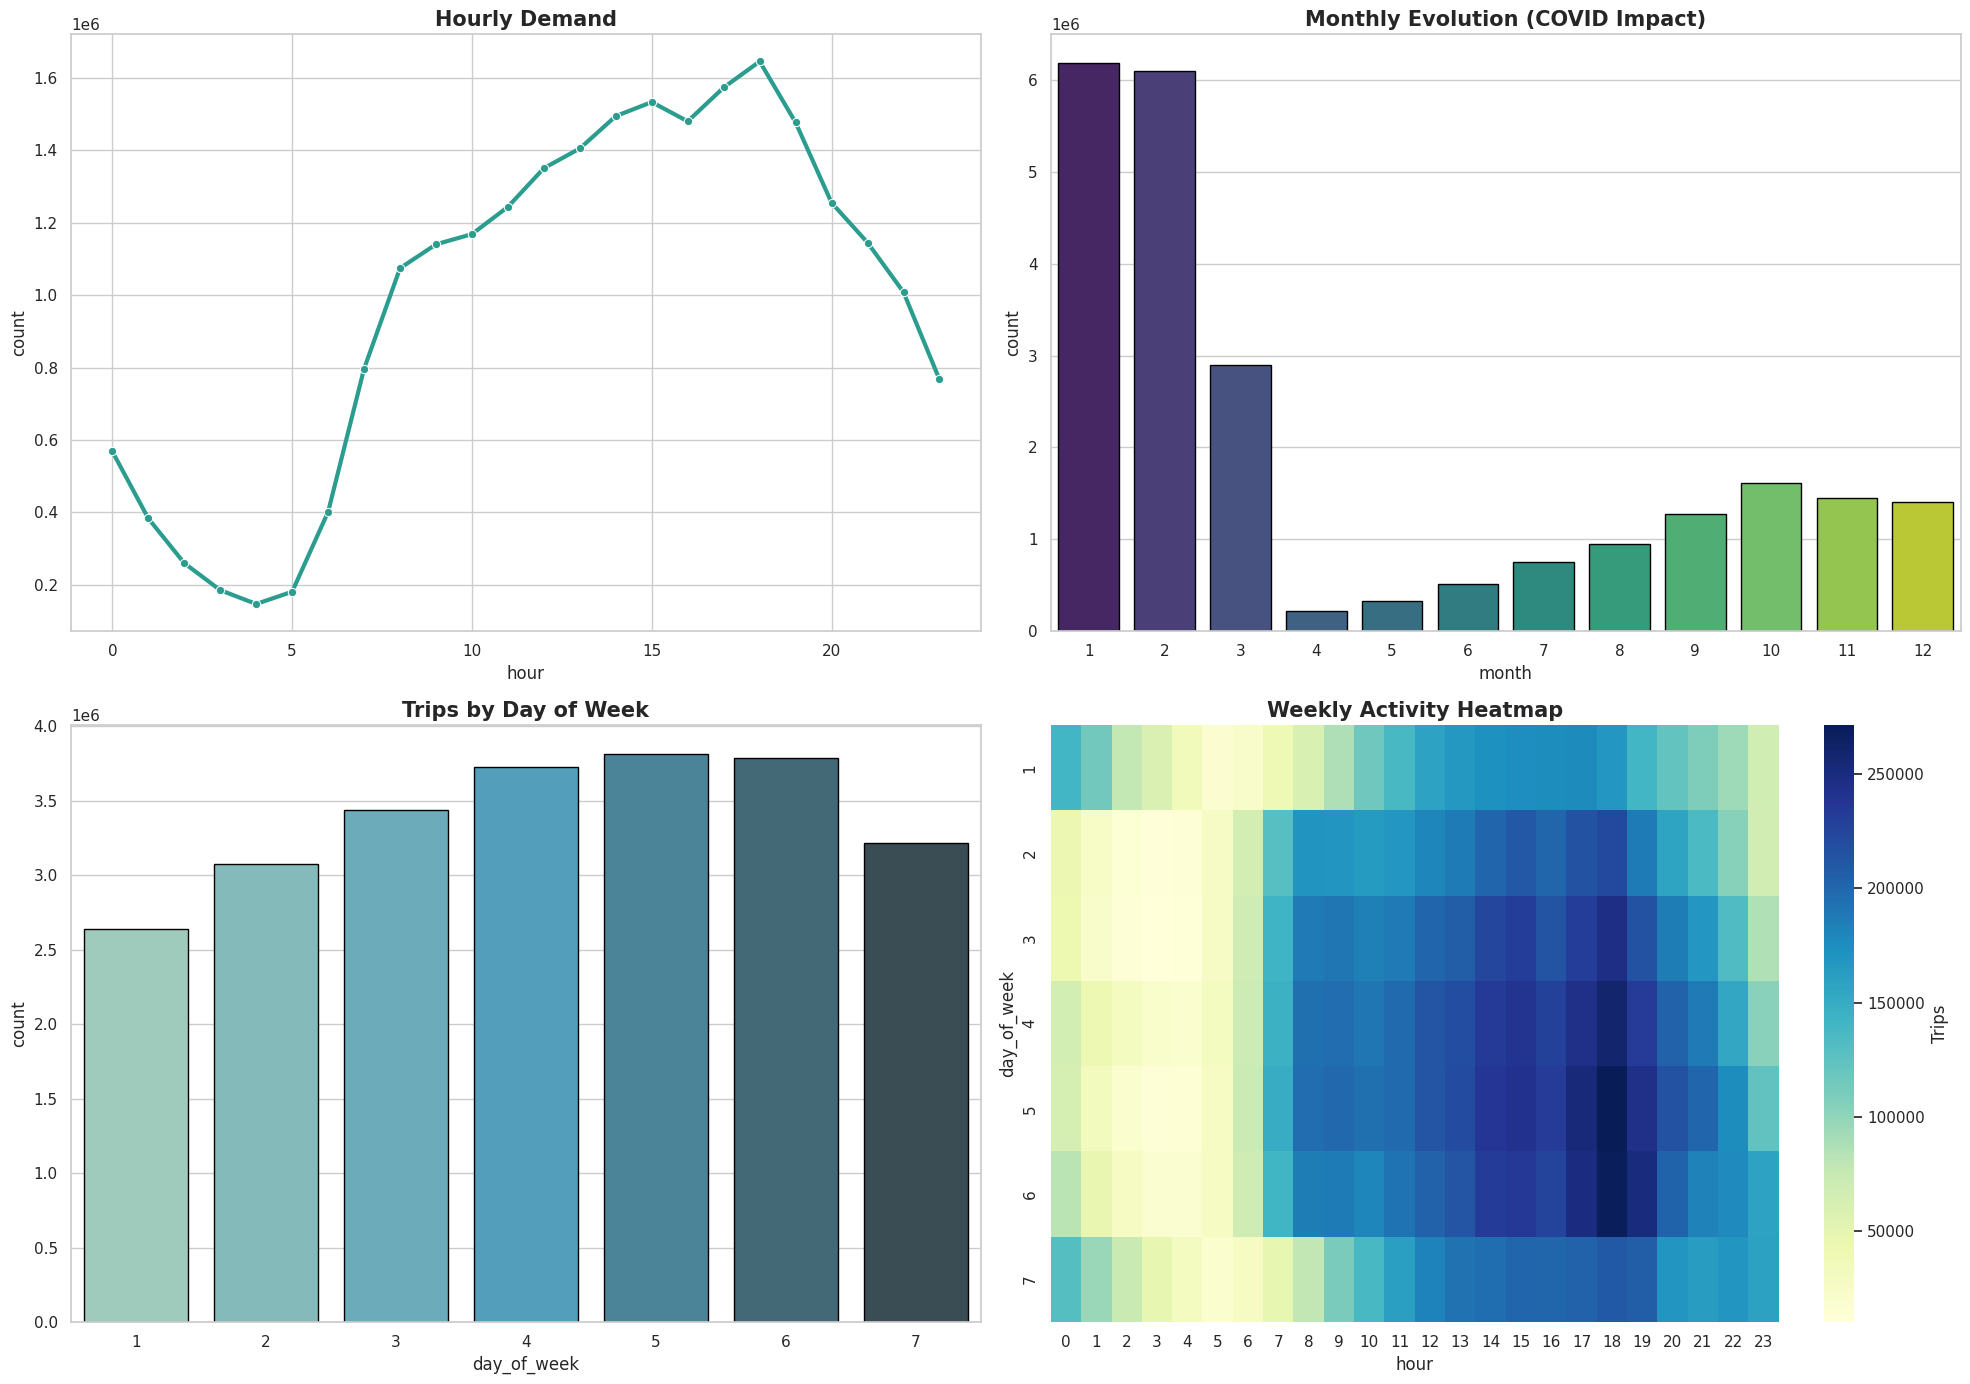

In [ ]:
sns.set_theme(style="whitegrid")

# FEATURE ENGINEERING
taxi_df_plot = taxi_df.withColumn(
    "hour", hour("tpep_pickup_datetime")
).withColumn(
    "day_of_week", dayofweek("tpep_pickup_datetime")
).withColumn(
    "month", month("tpep_pickup_datetime")
)

# AGGREGATIONS
hourly_data = taxi_df_plot.groupBy("hour") \
    .count() \
    .orderBy("hour") \
    .toPandas()

monthly_data = taxi_df_plot.groupBy("month") \
    .count() \
    .orderBy("month") \
    .toPandas()

weekday_data = taxi_df_plot.groupBy("day_of_week") \
    .count() \
    .orderBy("day_of_week") \
    .toPandas()

heatmap_df = taxi_df_plot.groupBy(
    "day_of_week",
    "hour"
).count().toPandas()

heatmap_pivot = heatmap_df.pivot(
    index="day_of_week",
    columns="hour",
    values="count"
)

# PLOTS
fig, ax = plt.subplots(2, 2, figsize=(20, 14))

# Hourly demand
sns.lineplot(
    data=hourly_data,
    x="hour",
    y="count",
    marker="o",
    linewidth=3,
    color="#2a9d8f",
    ax=ax[0,0]
)

ax[0,0].set_title(
    "Hourly Demand",
    fontsize=15,
    fontweight='bold'
)

# Monthly evolution
sns.barplot(
    data=monthly_data,
    x="month",
    y="count",
    palette="viridis",
    edgecolor="black",
    ax=ax[0,1]
)

ax[0,1].set_title(
    "Monthly Evolution (COVID Impact)",
    fontsize=15,
    fontweight='bold'
)

# Weekday demand
sns.barplot(
    data=weekday_data,
    x="day_of_week",
    y="count",
    palette="GnBu_d",
    edgecolor="black",
    ax=ax[1,0]
)

ax[1,0].set_title(
    "Trips by Day of Week",
    fontsize=15,
    fontweight='bold'
)

# Heatmap
sns.heatmap(
    heatmap_pivot,
    cmap="YlGnBu",
    ax=ax[1,1],
    cbar_kws={'label': 'Trips'}
)

ax[1,1].set_title(
    "Weekly Activity Heatmap",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Financial Analysis

Aggregating financial data...


/tmp/ipykernel_622019/1368115493.py:76: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_622019/1368115493.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


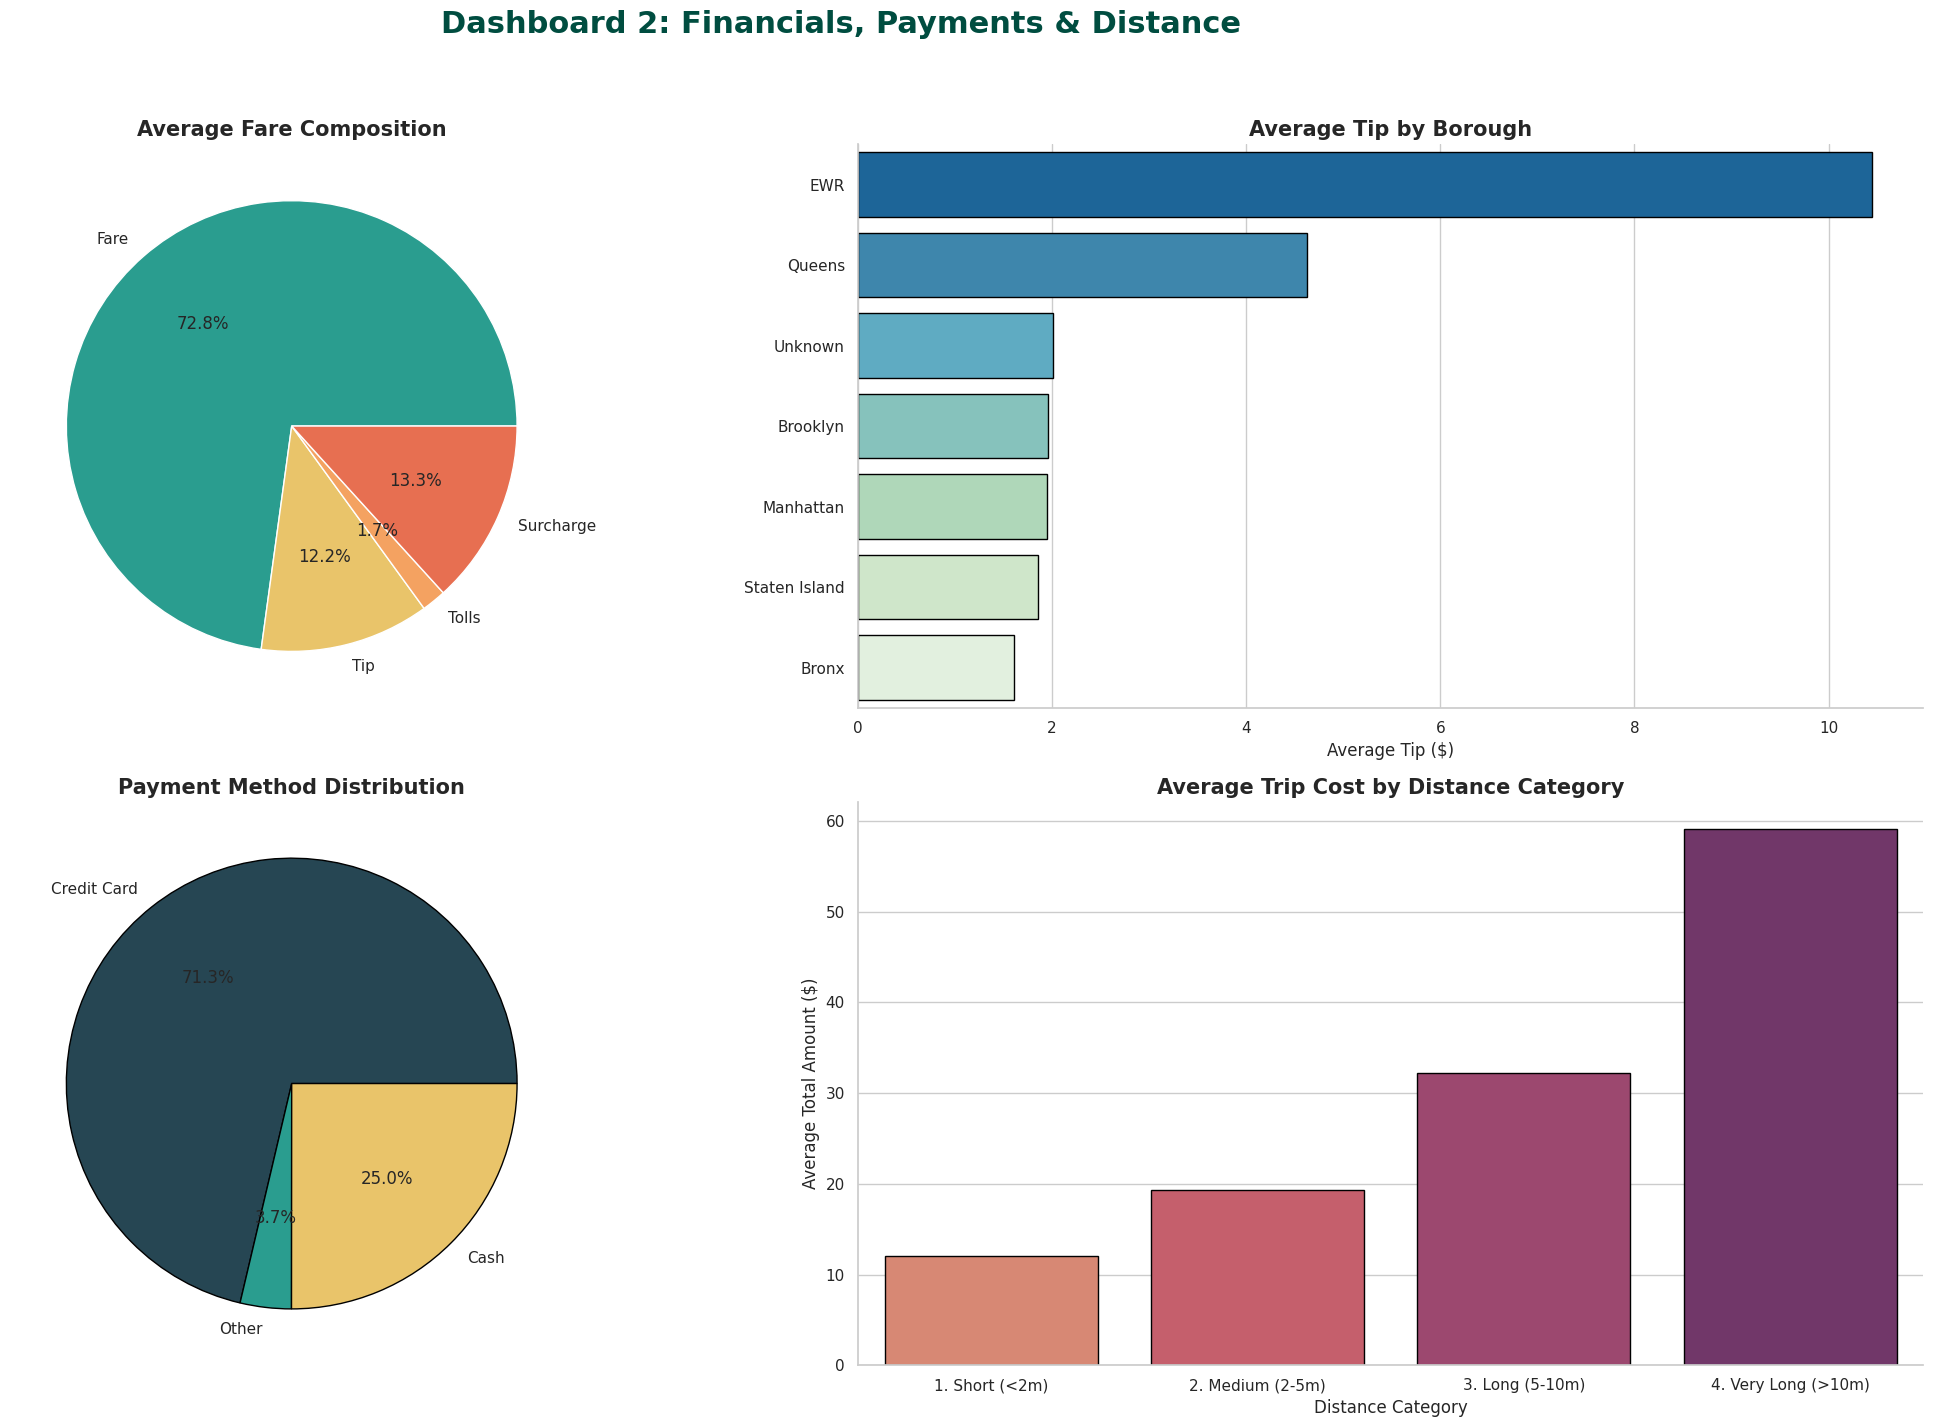

In [ ]:
# 1. FEATURE ENGINEERING
taxi_df_fin = taxi_df.withColumn("distance_category",
    when(col("trip_distance") < 2, "1. Short (<2m)")
    .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2. Medium (2-5m)")
    .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "3. Long (5-10m)")
    .otherwise("4. Very Long (>10m)")
).withColumn("payment_name",
    when(col("payment_type") == 1, "Credit Card")
    .when(col("payment_type") == 2, "Cash")
    .otherwise("Other")
)

# AGGREGATIONS (Spark -> Pandas)
print("Aggregating financial data...")

# 1. Fare Composition
finance_avg = taxi_df_fin.selectExpr(
    "avg(fare_amount) as Fare",
    "avg(tip_amount) as Tip",
    "avg(tolls_amount) as Tolls",
    "avg(congestion_surcharge) as Surcharge"
).toPandas()

# 2. Tip by Borough
tip_borough = taxi_df_fin.groupBy("PU_Borough") \
    .agg(avg("tip_amount").alias("avg_tip")) \
    .orderBy("avg_tip", ascending=False) \
    .toPandas()

# 3. Payment Distribution
payment_dist = taxi_df_fin.groupBy("payment_name") \
    .count() \
    .toPandas()

# 4. Cost by Distance Category
dist_category = taxi_df_fin.groupBy("distance_category") \
    .agg(avg("total_amount").alias("avg_cost")) \
    .orderBy("distance_category") \
    .toPandas()


# PLOTS
fig, ax = plt.subplots(2, 2, figsize=(22, 15))
fig.suptitle('Dashboard 2: Financials, Payments & Distance', fontsize=22, fontweight='bold', color='#004d40')

# --- Top Left: Fare composition ---
finance_avg.T.plot(
    kind='pie',
    subplots=True,
    ax=ax[0,0],
    autopct='%1.1f%%',
    legend=False,
    colors=['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']
)
ax[0,0].set_ylabel("")
ax[0,0].set_title("Average Fare Composition", fontsize=15, fontweight='bold')


# --- Top Right: Tip by borough ---
sns.barplot(
    data=tip_borough,
    x="avg_tip",
    y="PU_Borough",
    palette="GnBu_r",
    edgecolor="black",
    ax=ax[0,1]
)
ax[0,1].set_title("Average Tip by Borough", fontsize=15, fontweight='bold')
ax[0,1].set_xlabel("Average Tip ($)", fontsize=12)
ax[0,1].set_ylabel("")


# --- Bottom Left: Payment Method Distribution ---
ax[1,0].pie(
    payment_dist['count'],
    labels=payment_dist['payment_name'],
    autopct='%1.1f%%',
    colors=['#264653', '#2a9d8f', '#e9c46a'],
    wedgeprops={'edgecolor': 'black'}
)
ax[1,0].set_title("Payment Method Distribution", fontsize=15, fontweight='bold')


# --- Bottom Right: Cost by Distance Category ---
sns.barplot(
    data=dist_category,
    x="distance_category",
    y="avg_cost",
    ax=ax[1,1],
    palette="flare",
    edgecolor="black"
)
ax[1,1].set_title("Average Trip Cost by Distance Category", fontsize=15, fontweight='bold')
ax[1,1].set_xlabel("Distance Category", fontsize=12)
ax[1,1].set_ylabel("Average Total Amount ($)", fontsize=12)

for axes in [ax[0,1], ax[1,1]]:
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Geographic Analysis

Aggregating geographic and operational data...


/tmp/ipykernel_622019/997374233.py:81: FutureWarning:                           

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_622019/997374233.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_622019/997374233.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


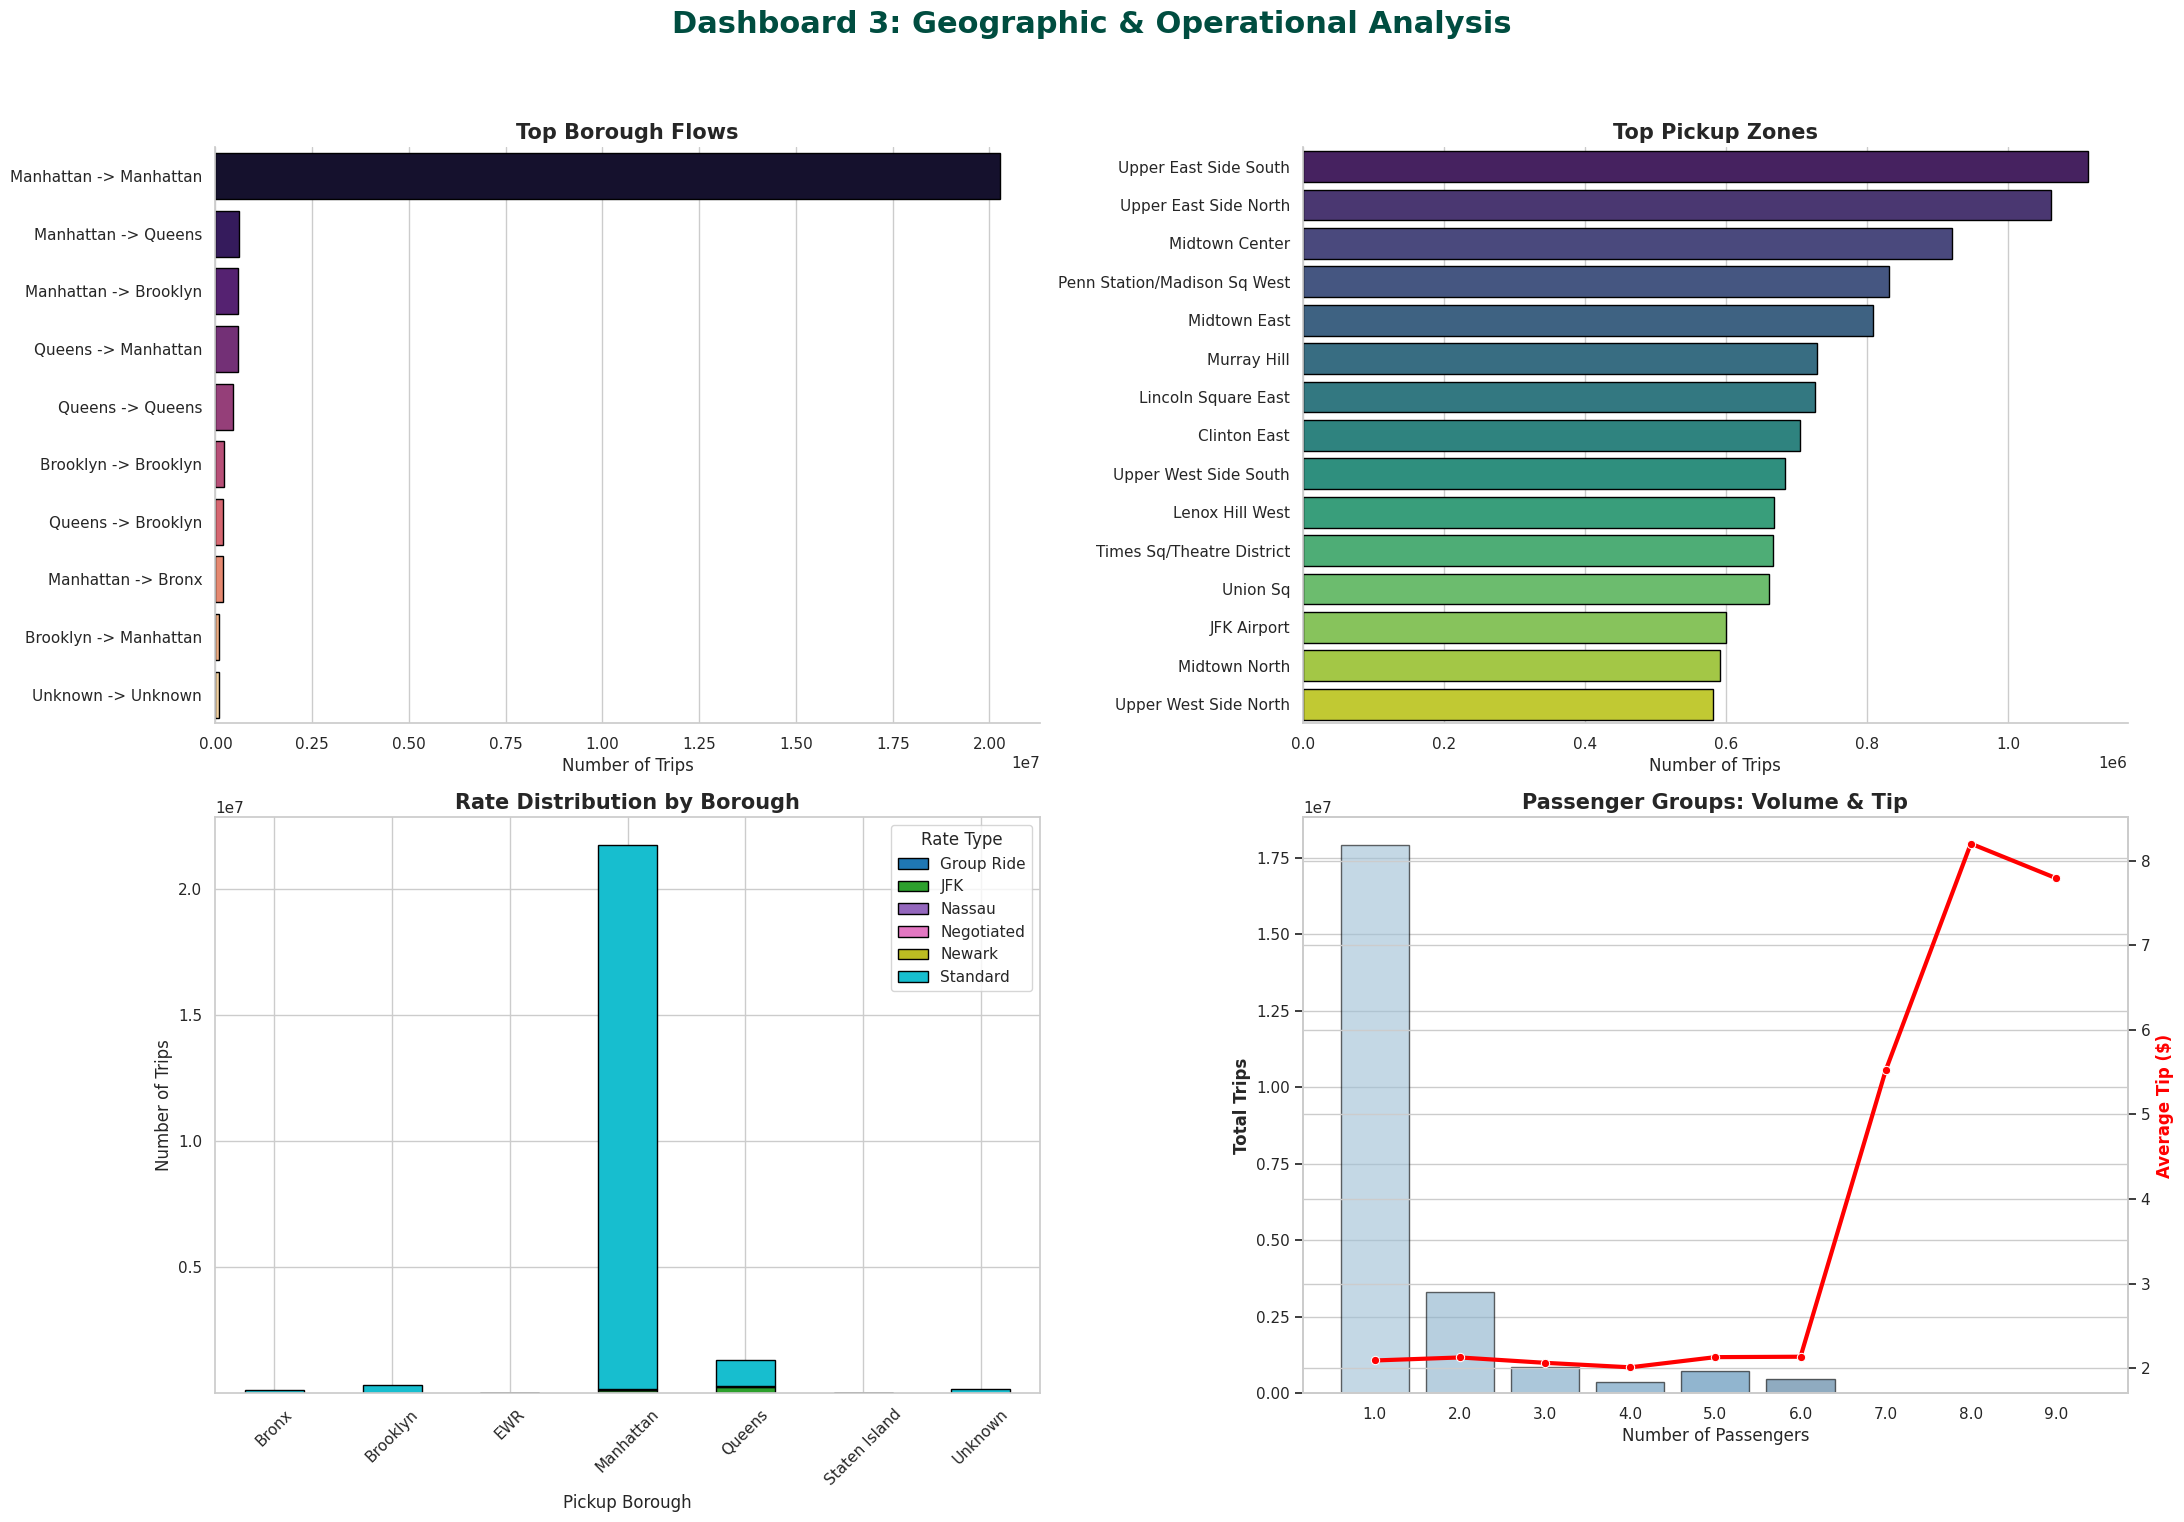

In [ ]:
print("Aggregating geographic and operational data...")

# 1. ROUTES (Top Borough Flows)
taxi_df_routes = taxi_df.withColumn(
    "route",
    concat(
        col("PU_Borough"),
        lit(" -> "),
        col("DO_Borough")
    )
)

route_data = taxi_df_routes.groupBy("route") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

# 2. TOP ZONES
top_zones = taxi_df.groupBy("PU_Zone") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(15) \
    .toPandas()

# 3. RATE CODES
taxi_df_rates = taxi_df.withColumn(
    "RateName",
    when(col("RatecodeID") == 1, "Standard")
    .when(col("RatecodeID") == 2, "JFK")
    .when(col("RatecodeID") == 3, "Newark")
    .when(col("RatecodeID") == 4, "Nassau")
    .when(col("RatecodeID") == 5, "Negotiated")
    .otherwise("Group Ride")
)

rate_dist = taxi_df_rates.groupBy(
    "PU_Borough",
    "RateName"
).count().toPandas()

rate_pivot = rate_dist.pivot(
    index="PU_Borough",
    columns="RateName",
    values="count"
).fillna(0)

# 4. PASSENGER GROUPS (Volume & Tip)
pass_group_data = taxi_df.groupBy("passenger_count") \
    .agg(
        avg("tip_amount").alias("avg_tip"),
        spark_count("*").alias("trip_count")
    ) \
    .orderBy("passenger_count") \
    .toPandas()


# PLOTS
fig, ax = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle('Dashboard 3: Geographic & Operational Analysis', fontsize=22, fontweight='bold', color='#004d40')

# --- Top Left: Top routes ---
sns.barplot(
    data=route_data,
    x="count",
    y="route",
    palette="magma",
    edgecolor="black",
    ax=ax[0,0]
)
ax[0,0].set_title("Top Borough Flows", fontsize=15, fontweight='bold')
ax[0,0].set_xlabel("Number of Trips", fontsize=12)
ax[0,0].set_ylabel("")

# --- Top Right: Top zones ---
sns.barplot(
    data=top_zones,
    x="count",
    y="PU_Zone",
    palette="viridis",
    edgecolor="black",
    ax=ax[0,1]
)
ax[0,1].set_title("Top Pickup Zones", fontsize=15, fontweight='bold')
ax[0,1].set_xlabel("Number of Trips", fontsize=12)
ax[0,1].set_ylabel("")

# --- Bottom Left: Stacked rate plot ---
rate_pivot.plot(
    kind='bar',
    stacked=True,
    colormap="tab10",
    edgecolor="black",
    ax=ax[1,0]
)
ax[1,0].set_title("Rate Distribution by Borough", fontsize=15, fontweight='bold')
ax[1,0].set_xlabel("Pickup Borough", fontsize=12)
ax[1,0].set_ylabel("Number of Trips", fontsize=12)
ax[1,0].legend(title="Rate Type", title_fontsize='12', fontsize='11')
ax[1,0].tick_params(axis='x', rotation=45)

# --- Bottom Right: Passenger Groups (Dual Axis) ---
sns.barplot(
    data=pass_group_data,
    x="passenger_count",
    y="trip_count",
    alpha=0.6,
    palette="Blues_d",
    edgecolor="black",
    ax=ax[1,1]
)
ax[1,1].set_ylabel("Total Trips", fontsize=12, fontweight='bold')
ax[1,1].set_xlabel("Number of Passengers", fontsize=12)

ax2 = ax[1,1].twinx()
sns.lineplot(
    data=pass_group_data,
    x=ax[1,1].get_xticks(),
    y="avg_tip",
    marker="o",
    color="red",
    linewidth=3,
    ax=ax2
)
ax2.set_ylabel("Average Tip ($)", fontsize=12, fontweight='bold', color="red")

ax[1,1].set_title("Passenger Groups: Volume & Tip", fontsize=15, fontweight='bold')

for axes in [ax[0,0], ax[0,1]]:
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Correlation Analysis

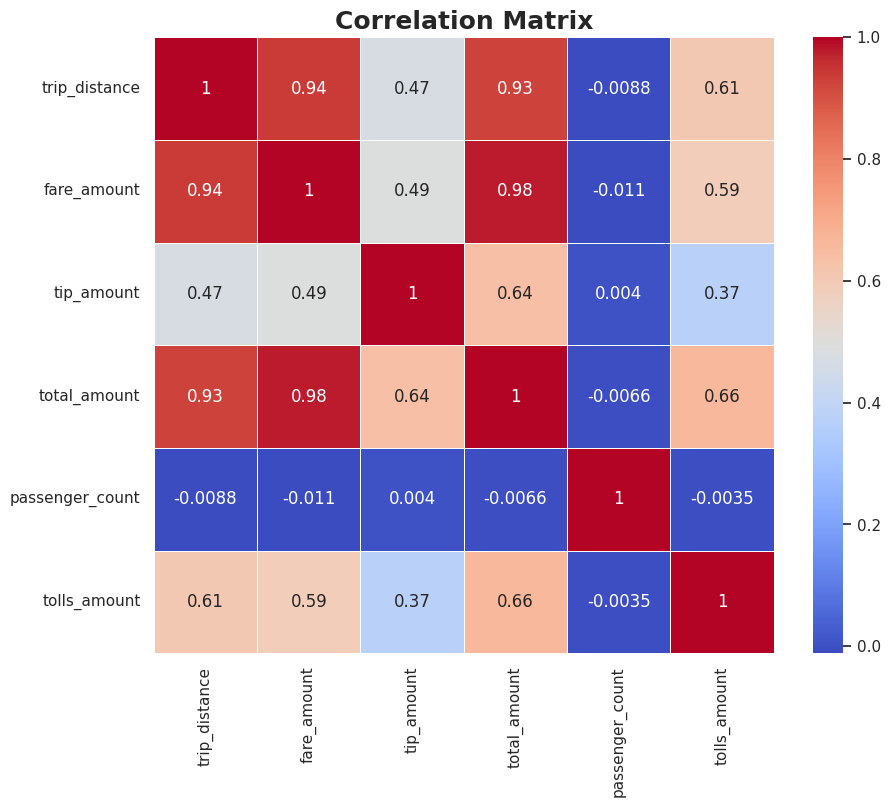

In [54]:
corr_cols = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "passenger_count",
    "tolls_amount"
]

corr_pd = taxi_df.select(corr_cols) \
    .sample(0.01) \
    .toPandas()

corr_matrix = corr_pd.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight='bold'
)

plt.show()